# Desenvolvimento de IA para Análise Preditiva
## Mini-projeto Avaliativo - Módulo 1 - Semana 8

In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import datetime
import random
from datetime import datetime, timedelta

import matplotlib.pyplot as plt 
import seaborn as sns 

#importar a funcao 'inspecionar_dados' que esta salva no arquivo 'funcoes.py'
from funcoes import inspecionar_dados

## RF01 – Criar ou Carregar o Dataset de Venda
Gerar um dataset sintético de vendas e inserir om dados intencionalmente sujos para limpeza

In [2]:
def gerar_dataset_vendas(n_registros=200, seed=42):

    random.seed(seed)
    np.random.seed(seed)

    produtos = [
        "Notebook",
        "Smartphone",
        "Tablet",
        "Monitor",
        "Teclado",
        "Mouse",
        "Headset"
    ]

    categorias = {
        "Notebook": "Computadores",
        "Smartphone": "Celulares",
        "Tablet": "Celulares",
        "Monitor": "Computadores",
        "Teclado": "Periféricos",
        "Mouse": "Periféricos",
        "Headset": "Periféricos"
    }

    preco_base = {
        "Notebook": 3500,
        "Smartphone": 2200,
        "Tablet": 1800,
        "Monitor": 1200,
        "Teclado": 250,
        "Mouse": 120,
        "Headset": 350
    }

    regioes = [
        "Sudeste",
        "Sul",
        "Nordeste",
        "Centro-Oeste",
        "Norte"
    ]

    clientes = [
        f"Cliente_{i:03d}"
        for i in range(1, 51)
    ]

    data_inicio = datetime(2024, 1, 1)

    dados = []

    for i in range(n_registros):

        produto = random.choice(produtos)

        quantidade = random.randint(1, 10)

        preco = round(
            preco_base[produto] * random.uniform(0.85, 1.15),
            2
        )

        data = data_inicio + timedelta(
            days=random.randint(0, 364)
        )

        cliente = random.choice(clientes)

        regiao = random.choice(regioes)

        # inclusao dos Dados sujos
        
        if random.random() < 0.05:
            quantidade = None

        if random.random() < 0.04:
            preco = None

        if random.random() < 0.03:
            produto = "  " + produto + "  "

        if random.random() < 0.02:
            data = "DATA INVÁLIDA"

        categoria = categorias.get(
            produto.strip(),
            "Outros"
        )

        if quantidade is not None and preco is not None:
            valor_total = round(
                quantidade * preco,
                2
            )
        else:
            valor_total = None

        dados.append({
            "data_venda": data,
            "cliente": cliente,
            "produto": produto,
            "categoria": categoria,
            "quantidade": quantidade,
            "preco_unitario": preco,
            "valor_total": valor_total,
            "regiao": regiao
        })

    df = pd.DataFrame(dados)

    return df

In [3]:
df = gerar_dataset_vendas()

#mostrar as 5 primeiras linhas do data frame
(df.head(5))

,data_venda,cliente,produto,categoria,quantidade,preco_unitario,valor_total,regiao
0,2024-05-20 00:00:00,Cliente_016,Mouse,Periféricos,2.0,102.90,205.80,Sul
1,2024-02-17 00:00:00,Cliente_014,Teclado,Periféricos,7.0,NaN,NaN,Sul
2,2024-10-28 00:00:00,Cliente_018,Teclado,Periféricos,7.0,229.03,1603.21,Sudeste
3,2024-07-13 00:00:00,Cliente_007,Smartphone,Celulares,6.0,1937.46,11624.76,Nordeste
4,2024-07-12 00:00:00,Cliente_006,Teclado,Periféricos,2.0,285.48,570.96,Norte


In [4]:
 
# Gerar e salvar 
df_bruto = gerar_dataset_vendas() 
df_bruto.to_csv("vendas.csv", index=False) 
print(f"Dataset gerado com {len(df_bruto)} registros.") 
(df_bruto.head()) 

Dataset gerado com 200 registros.


,data_venda,cliente,produto,categoria,quantidade,preco_unitario,valor_total,regiao
0,2024-05-20 00:00:00,Cliente_016,Mouse,Periféricos,2.0,102.90,205.80,Sul
1,2024-02-17 00:00:00,Cliente_014,Teclado,Periféricos,7.0,NaN,NaN,Sul
2,2024-10-28 00:00:00,Cliente_018,Teclado,Periféricos,7.0,229.03,1603.21,Sudeste
3,2024-07-13 00:00:00,Cliente_007,Smartphone,Celulares,6.0,1937.46,11624.76,Nordeste
4,2024-07-12 00:00:00,Cliente_006,Teclado,Periféricos,2.0,285.48,570.96,Norte


# Inspeção inicial do data set
primeiro fiz os comandos individuais (shape; colums;dtypes;info;describe;isnull;
depois por ultimo, criei uma funcao "inspecionar dados" para mostrar o resumo

In [5]:
#mostrar o tamanho 'linhas e colunas'
df.shape


(200, 8)

In [6]:
#mostrar nome das colunas
df.columns

Index(['data_venda', 'cliente', 'produto', 'categoria', 'quantidade',
       'preco_unitario', 'valor_total', 'regiao'],
      dtype='str')

In [7]:
#mostrar o tipo de dados de cada coluna
df.dtypes


data_venda         object
cliente               str
produto               str
categoria             str
quantidade        float64
preco_unitario    float64
valor_total       float64
regiao                str
dtype: object

In [8]:
#informacoes gerais
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data_venda      200 non-null    object 
 1   cliente         200 non-null    str    
 2   produto         200 non-null    str    
 3   categoria       200 non-null    str    
 4   quantidade      193 non-null    float64
 5   preco_unitario  197 non-null    float64
 6   valor_total     190 non-null    float64
 7   regiao          200 non-null    str    
dtypes: float64(3), object(1), str(4)
memory usage: 12.6+ KB


In [9]:
#mostrar estatisticas basicas
df.describe()

,quantidade,preco_unitario,valor_total
count,193.000000,197.000000,190.000000
mean,5.751295,1277.187157,7370.905316
std,2.975650,1189.264266,8382.473731
min,1.000000,102.900000,105.300000
25%,3.000000,257.420000,1071.320000
50%,6.000000,1078.560000,3195.330000
75%,8.000000,2027.630000,11518.410000
max,10.000000,4020.720000,35378.640000


In [10]:
#ver valores nulos
df.isnull().sum()

data_venda         0
cliente            0
produto            0
categoria          0
quantidade         7
preco_unitario     3
valor_total       10
regiao             0
dtype: int64

In [11]:
#criada a funcao inspecionar dados para chamar varios comandos de analise incial do df
#em cima foi feita uma por uma e abaixo fiz a funcao para chamar todas
#shape, colunas, tipo, valores nulos, estatisticas

inspecionar_dados(df)

# RF03 – Limpar e Tratar os Dados 
O projeto deverá realizar a limpeza dos dados. O estudante deve tratar ao menos os seguintes problemas: 

● Remover ou imputar linhas com valores nulos nas colunas críticas (quantidade, preco_unitario, valor total); 

● Remover linhas com datas inválidas (ex.: "DATA INVÁLIDA"); 

● Converter a coluna de data para o tipo datetime; 

● Remover espaços extras em colunas de texto com .str.strip(); 

● Registrar no console quantos registros foram removidos. 

In [12]:
### mostrar antes da remocao itens nulos
df.isnull().sum()


data_venda         0
cliente            0
produto            0
categoria          0
quantidade         7
preco_unitario     3
valor_total       10
regiao             0
dtype: int64

In [13]:
### apagar dados nulos das colunas "quantidade", "preco_unitario", "valor_total
#mostrar numero de registros removidos

linhas_antes = len(df)

df = df.dropna(
    subset=["quantidade", "preco_unitario", "valor_total"]
)

linhas_depois = len(df)

print(
    f"Registros removidos: "
    f"{linhas_antes - linhas_depois}"
)


Registros removidos: 10


In [14]:
#consulta APOS apagar dados nulos
df.isnull().sum()


data_venda        0
cliente           0
produto           0
categoria         0
quantidade        0
preco_unitario    0
valor_total       0
regiao            0
dtype: int64

In [15]:
## datas invalidas, consultar e exlcuir datas invelidas
print(df[df["data_venda"] == "DATA INVÁLIDA"])

print(
    (df["data_venda"] == "DATA INVÁLIDA").sum()
)


        data_venda      cliente     produto    categoria  quantidade  \
30   DATA INVÁLIDA  Cliente_009       Mouse  Periféricos         6.0   
32   DATA INVÁLIDA  Cliente_035  Smartphone    Celulares         6.0   
46   DATA INVÁLIDA  Cliente_044  Smartphone    Celulares         7.0   
76   DATA INVÁLIDA  Cliente_019      Tablet    Celulares         1.0   
121  DATA INVÁLIDA  Cliente_009     Headset  Periféricos         3.0   

     preco_unitario  valor_total    regiao  
30           110.59       663.54  Nordeste  
32          2058.09     12348.54  Nordeste  
46          2308.85     16161.95       Sul  
76          2056.12      2056.12       Sul  
121          309.04       927.12   Sudeste  
5


In [16]:
datas_invalidas = pd.to_datetime(
    df["data_venda"],
    errors="coerce"
).isna().sum()

print(f"Datas inválidas encontradas: {datas_invalidas}")

Datas inválidas encontradas: 5


In [17]:
#apagar datas invalidas
df = df.dropna(subset=["data_venda"])

In [18]:
#visualizar antes e depois de apagar invalidas
# 
print("Antes:", len(df))

df["data_venda"] = pd.to_datetime(
    df["data_venda"],
    errors="coerce"
)

df = df.dropna(subset=["data_venda"])

print("Depois:", len(df))

Antes: 190
Depois: 185


In [19]:
## retirar os espacos extras entre as palavras das colunas

colunas_texto = ["cliente", "produto", "categoria", "regiao"]

for coluna in colunas_texto:
    df[coluna] = df[coluna].str.strip()

In [20]:
linhas_iniciais = len(df)

# Remover datas inválidas
df = df.dropna(subset=["data_venda"])

# Remover nulos
df = df.dropna(
    subset=[
        "quantidade",
        "preco_unitario",
        "valor_total"
    ]
)

linhas_finais = len(df)

removidos = linhas_iniciais - linhas_finais

print(f"Registros removidos: {removidos}")

Registros removidos: 0


##FUNCAO LIMPAR DADOS - resume todos os comandos acima


In [21]:
def limpar_dados(df):

    print("\n=== INÍCIO DA LIMPEZA ===")

    # Quantidade inicial
    linhas_iniciais = len(df)

    # Mostrar nulos antes
    print("\nNulos antes da limpeza:")
    print(df.isnull().sum())

    # Verificar datas inválidas
    datas_invalidas = pd.to_datetime(
        df["data_venda"],
        errors="coerce"
    ).isna().sum()

    print(f"\nDatas inválidas encontradas: {datas_invalidas}")

    # Converter coluna para datetime
    df["data_venda"] = pd.to_datetime(
        df["data_venda"],
        errors="coerce"
    )

    # Remover datas inválidas
    df = df.dropna(
        subset=["data_venda"]
    )

    # Remover registros com nulos nas colunas críticas
    df = df.dropna(
        subset=[
            "quantidade",
            "preco_unitario",
            "valor_total"
        ]
    )

    # Remover espaços extras
    colunas_texto = [
        "cliente",
        "produto",
        "categoria",
        "regiao"
    ]

    for coluna in colunas_texto:
        df[coluna] = df[coluna].str.strip()

    # Quantidade final
    linhas_finais = len(df)

    removidos = linhas_iniciais - linhas_finais

    print(f"\nRegistros removidos: {removidos}")

    # Mostrar nulos após limpeza
    print("\nNulos após limpeza:")
    print(df.isnull().sum())

    print("\nShape após limpeza:")
    print(df.shape)

    print("\n=== LIMPEZA CONCLUÍDA ===")

    return df

# RF04 – Criar Colunas Derivadas com Transformações 
O projeto deverá criar novas colunas a partir dos dados existentes, enriquecendo o dataset 
para análise. Deve-se criar ao menos: 

● receita_total: quantidade * preco_unitario 

● mes: mês extraído da data (número ou nome) 


● trimestre: trimestre do ano (Q1, Q2, Q3, Q4) 
● ano: ano extraído da data 

● faixa_receita_item: classificação da receita por item usando transformação condicional 

In [22]:
#criar uma nova coluna chamada receita total que é o resultado de quantidade x preço unitario

def criar_receita_total(df):

    df["receita_total"] = (
        df["quantidade"] *
        df["preco_unitario"]
    )

    return df

In [23]:
df = criar_receita_total(df)

In [24]:
df.head()

,data_venda,cliente,produto,categoria,quantidade,preco_unitario,valor_total,regiao,receita_total
0,2024-05-20,Cliente_016,Mouse,Periféricos,2.0,102.90,205.80,Sul,205.80
2,2024-10-28,Cliente_018,Teclado,Periféricos,7.0,229.03,1603.21,Sudeste,1603.21
3,2024-07-13,Cliente_007,Smartphone,Celulares,6.0,1937.46,11624.76,Nordeste,11624.76
4,2024-07-12,Cliente_006,Teclado,Periféricos,2.0,285.48,570.96,Norte,570.96
5,2024-04-26,Cliente_050,Smartphone,Celulares,2.0,1900.24,3800.48,Nordeste,3800.48


In [25]:
df["data_venda"] = pd.to_datetime(
    df["data_venda"],
    errors="coerce"
)

In [26]:
#criar as novas colunas mes, trimestre e ano

def criar_colunas_data(df):

    df["mes"] = df["data_venda"].dt.month

    df["trimestre"] = (
        "Q" +
        df["data_venda"].dt.quarter.astype(str)
    )

    df["ano"] = df["data_venda"].dt.year

    return df

In [27]:
df["data_venda"] = pd.to_datetime(
    df["data_venda"],
    errors="coerce"
)

In [28]:
df = criar_colunas_data(df)

In [29]:
df.head()

,data_venda,cliente,produto,categoria,quantidade,preco_unitario,valor_total,regiao,receita_total,mes,trimestre,ano
0,2024-05-20,Cliente_016,Mouse,Periféricos,2.0,102.90,205.80,Sul,205.80,5,Q2,2024
2,2024-10-28,Cliente_018,Teclado,Periféricos,7.0,229.03,1603.21,Sudeste,1603.21,10,Q4,2024
3,2024-07-13,Cliente_007,Smartphone,Celulares,6.0,1937.46,11624.76,Nordeste,11624.76,7,Q3,2024
4,2024-07-12,Cliente_006,Teclado,Periféricos,2.0,285.48,570.96,Norte,570.96,7,Q3,2024
5,2024-04-26,Cliente_050,Smartphone,Celulares,2.0,1900.24,3800.48,Nordeste,3800.48,4,Q2,2024


In [30]:
# criar a nova coluna : faixa_receita_item: classificação da receita por item usando transformação condicional

def classificar_receita(valor):

    if valor < 1000:
        return "Baixa"

    elif valor < 5000:
        return "Média"

    else:
        return "Alta"

df["faixa_receita_item"] = (
    df["receita_total"]
    .apply(classificar_receita)
)

In [31]:
print(
    df[
        ["receita_total", "faixa_receita_item"]
    ].head(10)
)

    receita_total faixa_receita_item
0          205.80              Baixa
2         1603.21              Média
3        11624.76               Alta
4          570.96              Baixa
5         3800.48              Média
6         6471.36               Alta
7          899.04              Baixa
8          382.03              Baixa
9          929.92              Baixa
10        1958.88              Média


In [32]:
(df.head())

,data_venda,cliente,produto,categoria,quantidade,preco_unitario,valor_total,regiao,receita_total,mes,trimestre,ano,faixa_receita_item
0,2024-05-20,Cliente_016,Mouse,Periféricos,2.0,102.90,205.80,Sul,205.80,5,Q2,2024,Baixa
2,2024-10-28,Cliente_018,Teclado,Periféricos,7.0,229.03,1603.21,Sudeste,1603.21,10,Q4,2024,Média
3,2024-07-13,Cliente_007,Smartphone,Celulares,6.0,1937.46,11624.76,Nordeste,11624.76,7,Q3,2024,Alta
4,2024-07-12,Cliente_006,Teclado,Periféricos,2.0,285.48,570.96,Norte,570.96,7,Q3,2024,Baixa
5,2024-04-26,Cliente_050,Smartphone,Celulares,2.0,1900.24,3800.48,Nordeste,3800.48,4,Q2,2024,Média


In [33]:
df.to_csv(
    "dataset_vendas_tratado.csv",
    index=False
)

#CRIAR A FUNCAO TRANSFORMAR DADOS

In [34]:
def transformar_dados(df):

    df["receita_total"] = (
        df["quantidade"] *
        df["preco_unitario"]
    )

    df["mes"] = df["data_venda"].dt.month

    df["trimestre"] = (
        "Q" +
        df["data_venda"].dt.quarter.astype(str)
    )

    df["ano"] = df["data_venda"].dt.year

    df["faixa_receita_item"] = (
        df["receita_total"]
        .apply(
            lambda x:
                "Baixa" if x < 1000
                else "Média" if x < 5000
                else "Alta"
        )
    )

    return df

In [35]:
df.head()

,data_venda,cliente,produto,categoria,quantidade,preco_unitario,valor_total,regiao,receita_total,mes,trimestre,ano,faixa_receita_item
0,2024-05-20,Cliente_016,Mouse,Periféricos,2.0,102.90,205.80,Sul,205.80,5,Q2,2024,Baixa
2,2024-10-28,Cliente_018,Teclado,Periféricos,7.0,229.03,1603.21,Sudeste,1603.21,10,Q4,2024,Média
3,2024-07-13,Cliente_007,Smartphone,Celulares,6.0,1937.46,11624.76,Nordeste,11624.76,7,Q3,2024,Alta
4,2024-07-12,Cliente_006,Teclado,Periféricos,2.0,285.48,570.96,Norte,570.96,7,Q3,2024,Baixa
5,2024-04-26,Cliente_050,Smartphone,Celulares,2.0,1900.24,3800.48,Nordeste,3800.48,4,Q2,2024,Média


#RF05 – Calcular Métricas Agregadas (groupby) 

O sistema deverá calcular e exibir métricas agrupadas por diferentes dimensões. Deve-se 
gerar ao menos: 

● Receita total e quantidade vendida por mês; 

● Receita total por produto (top 5); 

● Receita total por categoria; 

● Receita total por região. 

In [36]:
print("\n=== RECEITA E QUANTIDADE POR MÊS ===")

print(
    df.groupby("mes")
      .agg({
          "receita_total": "sum",
          "quantidade": "sum"
      })
)

print("\n=== TOP 5 PRODUTOS ===")

print(
    df.groupby("produto")["receita_total"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print("\n=== RECEITA POR CATEGORIA ===")

print(
    df.groupby("categoria")["receita_total"]
      .sum()
      .sort_values(ascending=False)
)

print("\n=== RECEITA POR REGIÃO ===")

print(
    df.groupby("regiao")["receita_total"]
      .sum()
      .sort_values(ascending=False)
)


=== RECEITA E QUANTIDADE POR MÊS ===
     receita_total  quantidade
mes                           
1        149359.17       108.0
2        174702.68       130.0
3         97550.03        85.0
4         75696.78        69.0
5         39390.11        42.0
6        118670.51        94.0
7        121455.71       101.0
8        114086.50        86.0
9         58376.22        62.0
10       199277.39       111.0
11       159033.64       104.0
12        60716.00        77.0

=== TOP 5 PRODUTOS ===
produto
Notebook      540697.12
Smartphone    291135.08
Tablet        276703.29
Monitor       130520.70
Headset        71676.81
Name: receita_total, dtype: float64

=== RECEITA POR CATEGORIA ===
categoria
Computadores    671217.82
Celulares       567838.37
Periféricos     129258.55
Name: receita_total, dtype: float64

=== RECEITA POR REGIÃO ===
regiao
Sudeste         292048.75
Sul             291608.36
Nordeste        290884.42
Centro-Oeste    259420.54
Norte           234352.67
Name: receita_total,

In [37]:
def calcular_metricas_agregadas(df):

    print("\n=== RECEITA E QUANTIDADE POR MÊS ===")

    receita_mes = (
        df.groupby("mes")
          .agg({
              "receita_total": "sum",
              "quantidade": "sum"
          })
    )

    print(receita_mes)

    print("\n=== TOP 5 PRODUTOS ===")

    top5_produtos = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
    )

    print(top5_produtos)

    print("\n=== RECEITA POR CATEGORIA ===")

    receita_categoria = (
        df.groupby("categoria")["receita_total"]
          .sum()
          .sort_values(ascending=False)
    )

    print(receita_categoria)

    print("\n=== RECEITA POR REGIÃO ===")

    receita_regiao = (
        df.groupby("regiao")["receita_total"]
          .sum()
          .sort_values(ascending=False)
    )

    print(receita_regiao)

    return {
        "receita_mes": receita_mes,
        "top5_produtos": top5_produtos,
        "receita_categoria": receita_categoria,
        "receita_regiao": receita_regiao
    }

# RF06 – Segmentar Clientes por Nível de Gasto 
O sistema deverá agrupar os dados por cliente, calcular o total gasto por cada um e 
classificá-los em segmentos. 

Deve-se usar ao menos uma função lambda e uma transformação condicional. 

In [38]:
# Agrupar por cliente
clientes = (
    df.groupby("cliente")["receita_total"]
      .sum()
      .reset_index()
)

# Segmentar clientes
clientes["segmento"] = clientes["receita_total"].apply(
    lambda x:
        "Bronze" if x < 5000
        else "Prata" if x <= 15000
        else "Ouro"
)

print("\n=== SEGMENTAÇÃO DE CLIENTES ===")
print(clientes.head())

print("\n=== CLIENTES POR SEGMENTO ===")
print(clientes["segmento"].value_counts())

print("\n=== RECEITA POR SEGMENTO ===")
print(
    clientes.groupby("segmento")["receita_total"]
    .sum()
)


=== SEGMENTAÇÃO DE CLIENTES ===
       cliente  receita_total segmento
0  Cliente_001       28218.67     Ouro
1  Cliente_002         257.42   Bronze
2  Cliente_003       63586.81     Ouro
3  Cliente_004       11499.66    Prata
4  Cliente_005       33351.88     Ouro

=== CLIENTES POR SEGMENTO ===
segmento
Ouro      30
Prata     13
Bronze     5
Name: count, dtype: int64

=== RECEITA POR SEGMENTO ===
segmento
Bronze      12827.46
Ouro      1221570.01
Prata      133917.27
Name: receita_total, dtype: float64


In [39]:
def segmentar_clientes(df):

    # Agrupar por cliente
    clientes = (
        df.groupby("cliente")["receita_total"]
          .sum()
          .reset_index()
    )

    # Classificação dos clientes
    clientes["segmento"] = clientes["receita_total"].apply(
        lambda x:
            "Bronze" if x < 5000
            else "Prata" if x <= 15000
            else "Ouro"
    )

    print("\n=== SEGMENTAÇÃO DE CLIENTES ===")
    print(clientes.head())

    print("\n=== CLIENTES POR SEGMENTO ===")
    print(clientes["segmento"].value_counts())

    print("\n=== RECEITA POR SEGMENTO ===")
    print(
        clientes.groupby("segmento")["receita_total"]
                .sum()
                .sort_values(ascending=False)
    )

    return clientes

#RF07 – Calcular Estatísticas com NumPy 

O projeto deverá usar NumPy diretamente para calcular estatísticas sobre os dados. Deve-se 
demonstrar ao menos: 

● Conversão de uma coluna do DataFrame para array NumPy; 

● Uso de operações vetorizadas (sem loops); 

● Uso de broadcasting ou operações entre arrays; 

● Pelo menos 3 funções NumPy (mean, std, median, percentile, sum, etc.).

In [40]:

# Converter para array NumPy
receitas = df["receita_total"].to_numpy()

print("\n=== ESTATÍSTICAS NUMPY ===")

# Funções NumPy
print(f"receita media por venda: {np.std(receitas):.2f}")

print("receita Mediana por venda:", np.median(receitas))

print(f"Desvio padrão: {np.std(receitas):.2f}")

print("Percentil 25:", np.percentile(receitas, 25))

print("Percentil 75:", np.percentile(receitas, 75))

print(f"receita total: {np.std(receitas):.2f}")


# Operação vetorizada
receitas_bonus = receitas * 1.10

print("\nPrimeiras receitas com bônus de 10%:")

print(receitas_bonus[:5])

# Broadcasting
receitas_liquidas = receitas - 100

print("\nPrimeiras receitas após desconto fixo de R$100:")

print(receitas_liquidas[:5])


=== ESTATÍSTICAS NUMPY ===
receita media por venda: 8403.12
receita Mediana por venda: 3241.44
Desvio padrão: 8403.12
Percentil 25: 1088.72
Percentil 75: 11199.36
receita total: 8403.12

Primeiras receitas com bônus de 10%:
[  226.38   1763.531 12787.236   628.056  4180.528]

Primeiras receitas após desconto fixo de R$100:
[  105.8   1503.21 11524.76   470.96  3700.48]


In [41]:
def calcular_estatisticas_numpy(df):

    # Converter coluna para array NumPy
    receitas = df["receita_total"].to_numpy()

    print("\n=== ESTATÍSTICAS NUMPY ===")

    # Estatísticas
    print(
        f"Receita média por venda: "
        f"{np.mean(receitas):.2f}"
    )

    print(
        f"Receita mediana por venda: "
        f"{np.median(receitas):.2f}"
    )

    print(
        f"Desvio padrão: "
        f"{np.std(receitas):.2f}"
    )

    print(
        f"Percentil 25: "
        f"{np.percentile(receitas, 25):.2f}"
    )

    print(
        f"Percentil 75: "
        f"{np.percentile(receitas, 75):.2f}"
    )

    print(
        f"Receita total: "
        f"{np.sum(receitas):.2f}"
    )

    # Operação vetorizada
    receitas_bonus = receitas * 1.10

    print("\nPrimeiras receitas com bônus de 10%:")

    print(receitas_bonus[:5])

    # Broadcasting
    receitas_liquidas = receitas - 100

    print("\nPrimeiras receitas após desconto fixo de R$100:")

    print(receitas_liquidas[:5])

    return {
        "media": np.mean(receitas),
        "mediana": np.median(receitas),
        "desvio_padrao": np.std(receitas),
        "percentil_25": np.percentile(receitas, 25),
        "percentil_75": np.percentile(receitas, 75),
        "receita_total": np.sum(receitas)
    }

#RF08 – Criar Visualizações com Matplotlib e Seaborn 

O projeto deverá gerar ao menos 3 gráficos distintos, exportados como arquivos PNG. 
Os gráficos devem ser informativos, com título, rótulos de eixos e legenda onde aplicável. 
Gráficos obrigatórios: 

1. Gráfico de linha: Receita total por mês ao longo do tempo; 

2. Gráfico de barras: Top 5 produtos ou categorias por receita; 

3. Gráfico adicional (à escolha): dispersão, histograma, boxplot, mapa de calor 
(heatmap), pizza, ou barras agrupadas.


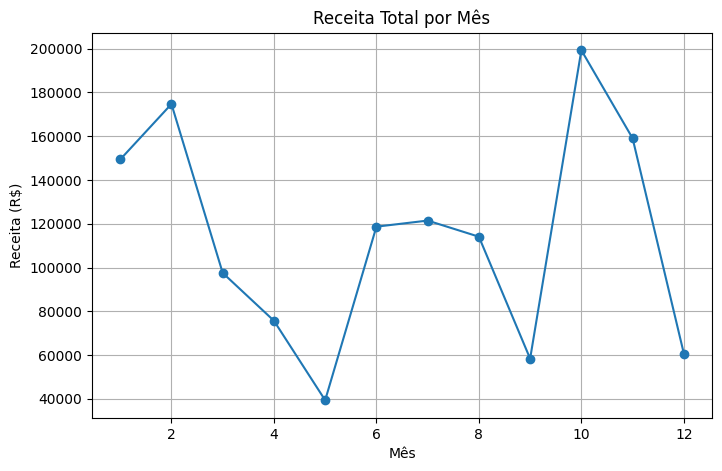

In [42]:
# Gráfico de Linha – Receita Total por Mês

# Receita por mês
receita_mes = (
    df.groupby("mes")["receita_total"]
      .sum()
)

plt.figure(figsize=(8,5))

plt.plot(
    receita_mes.index,
    receita_mes.values,
    marker="o"
)

plt.title("Receita Total por Mês")
plt.xlabel("Mês")
plt.ylabel("Receita (R$)")
plt.grid(True)

plt.savefig("grafico_receita_mes.png")

plt.show()

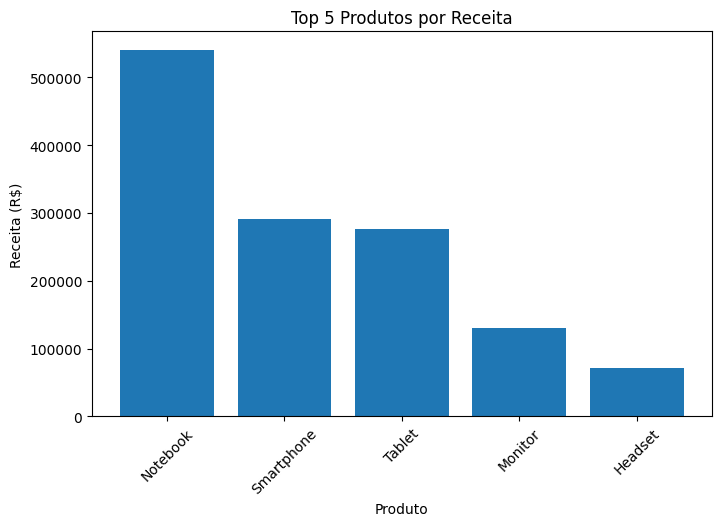

In [43]:
# Gráfico de Barras – Top 5 Produtos por Receita

top5_produtos = (
    df.groupby("produto")["receita_total"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

plt.figure(figsize=(8,5))

plt.bar(
    top5_produtos.index,
    top5_produtos.values
)

plt.title("Top 5 Produtos por Receita")
plt.xlabel("Produto")
plt.ylabel("Receita (R$)")

plt.xticks(rotation=45)

plt.savefig("grafico_top5_produtos.png")

plt.show()

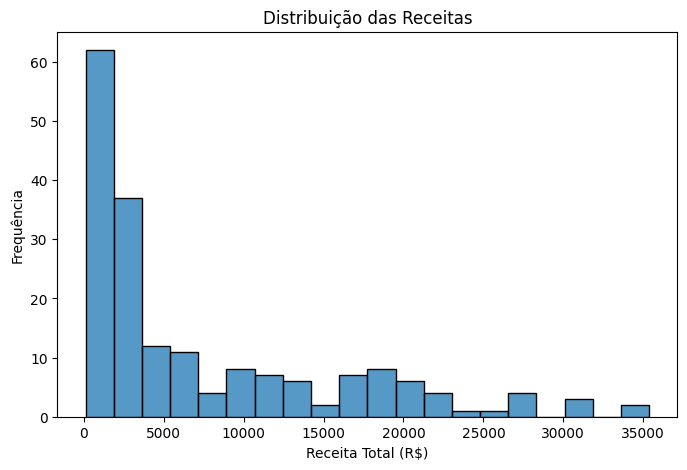

In [44]:
# Histograma – Distribuição das Receitas

plt.figure(figsize=(8,5))

sns.histplot(
    df["receita_total"],
    bins=20
)

plt.title("Distribuição das Receitas")
plt.xlabel("Receita Total (R$)")
plt.ylabel("Frequência")

plt.savefig("grafico_histograma_receitas.png")

plt.show()

In [45]:
print("Gráfico 1 salvo: grafico_receita_mes.png")
print("Gráfico 2 salvo: grafico_top5_produtos.png")
print("Gráfico 3 salvo: grafico_histograma_receitas.png")

Gráfico 1 salvo: grafico_receita_mes.png
Gráfico 2 salvo: grafico_top5_produtos.png
Gráfico 3 salvo: grafico_histograma_receitas.png


In [46]:
def gerar_graficos(df):

    print("\n=== GERANDO GRÁFICOS ===")

    # --------------------------------------------------
    # Gráfico 1 - Receita Total por Mês
    # --------------------------------------------------

    receita_mes = (
        df.groupby("mes")["receita_total"]
          .sum()
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        receita_mes.index,
        receita_mes.values,
        marker="o"
    )

    plt.title("Receita Total por Mês")
    plt.xlabel("Mês")
    plt.ylabel("Receita (R$)")
    plt.grid(True)

    plt.savefig("grafico_receita_mes.png")

    plt.show()

    # --------------------------------------------------
    # Gráfico 2 - Top 5 Produtos
    # --------------------------------------------------

    top5_produtos = (
        df.groupby("produto")["receita_total"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
    )

    plt.figure(figsize=(8, 5))

    plt.bar(
        top5_produtos.index,
        top5_produtos.values
    )

    plt.title("Top 5 Produtos por Receita")
    plt.xlabel("Produto")
    plt.ylabel("Receita (R$)")

    plt.xticks(rotation=45)

    plt.savefig("grafico_top5_produtos.png")

    plt.show()

    # --------------------------------------------------
    # Gráfico 3 - Histograma
    # --------------------------------------------------

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df["receita_total"],
        bins=20
    )

    plt.title("Distribuição das Receitas")
    plt.xlabel("Receita Total (R$)")
    plt.ylabel("Frequência")

    plt.savefig(
        "grafico_histograma_receitas.png"
    )

    plt.show()

    print("\nArquivos gerados:")
    print("✓ grafico_receita_mes.png")
    print("✓ grafico_top5_produtos.png")
    print("✓ grafico_histograma_receitas.png")

# RF09 – Criar uma Classe para o Pipeline 

O estudante deverá criar ao menos uma classe que encapsule parte do pipeline de análise. 

A classe deve ter construtor (__init__), atributos e métodos que usem self. 

In [47]:
class AnaliseVendas:

    def __init__(self, df):
        self.df = df

    def mostrar_dimensoes(self):
        print("\n=== DIMENSÕES ===")
        print(self.df.shape)

    def mostrar_colunas(self):
        print("\n=== COLUNAS ===")
        print(self.df.columns)

    def receita_total(self):
        total = self.df["receita_total"].sum()

        print("\n=== RECEITA TOTAL ===")
        print(f"R$ {total:.2f}")

    def top_produtos(self):

        top5 = (
            self.df.groupby("produto")["receita_total"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
        )

        print("\n=== TOP 5 PRODUTOS ===")
        print(top5)

In [48]:
analise = AnaliseVendas(df)

In [49]:
analise.mostrar_dimensoes()

analise.mostrar_colunas()

analise.receita_total()

analise.top_produtos()


=== DIMENSÕES ===
(185, 13)

=== COLUNAS ===
Index(['data_venda', 'cliente', 'produto', 'categoria', 'quantidade',
       'preco_unitario', 'valor_total', 'regiao', 'receita_total', 'mes',
       'trimestre', 'ano', 'faixa_receita_item'],
      dtype='str')

=== RECEITA TOTAL ===
R$ 1368314.74

=== TOP 5 PRODUTOS ===
produto
Notebook      540697.12
Smartphone    291135.08
Tablet        276703.29
Monitor       130520.70
Headset        71676.81
Name: receita_total, dtype: float64


# RF10 – Usar Herança 
O estudante deverá criar uma classe que herde de outra, adicionando funcionalidades 
específicas. 

Exemplo: uma classe AnalisadorComProjecao que herda de AnalisadorDeVendas 
e adiciona uma projeção simples de tendência.

In [50]:
class AnaliseVendas:

    def __init__(self, df):
        self.df = df

    def receita_total(self):
        return self.df["receita_total"].sum()

    def top5_produtos(self):
        return (
            self.df.groupby("produto")["receita_total"]
            .sum()
            .sort_values(ascending=False)
            .head(5)
        )

In [51]:
class AnaliseComProjecao(AnaliseVendas):

    def projecao_receita(self, percentual=10):

        receita_atual = self.receita_total()

        receita_futura = receita_atual * (
            1 + percentual/100
        )

        return receita_futura

In [52]:
analise = AnaliseComProjecao(df)

print("Receita atual:")
print(analise.receita_total())

print("\nReceita projetada:")
print(
    analise.projecao_receita(15)
)

Receita atual:
1368314.7399999998

Receita projetada:
1573561.9509999997


In [53]:
def executar_analise_poo(df):

    analisador = AnalisadorComProjecao(df)

    print("\n=== DIMENSÕES ===")
    analisador.mostrar_dimensoes()

    print("\n=== COLUNAS ===")
    analisador.mostrar_colunas()

    print("\n=== RECEITA TOTAL ===")
    print(
        f"R$ {analisador.receita_total():.2f}"
    )

    print("\n=== TOP 5 PRODUTOS ===")
    print(
        analisador.top5_produtos()
    )

    print("\n=== PROJEÇÃO DE RECEITA (15%) ===")
    print(
        f"R$ {analisador.projecao_receita(15):.2f}"
    )

    return analisador

# RF11 – Usar Funções Lambda e Funções de Ordem Superior 

O projeto deverá usar funções lambda em ao menos dois contextos distintos, e demonstrar 
uma função que recebe outra função como parâmetro (equivalente ao conceito de callback). 

Lambda 1: utilizada para classificar clientes em Bronze, Prata e Ouro.

Lambda 2: utilizada para ordenar produtos pela receita total.

Função de ordem superior: aplicar_estatistica() recebe uma função como parâmetro (np.mean, np.std, np.median) e executa o cálculo desejado.

In [54]:
# Lambda 1 - Segmentação de clientes
clientes["segmento"] = clientes["receita_total"].apply(
    lambda x:
        "Bronze" if x < 5000
        else "Prata" if x <= 15000
        else "Ouro"
)

# Lambda 2 - Ordenação de produtos
top_produtos = sorted(
    df.groupby("produto")["receita_total"].sum().items(),
    key=lambda x: x[1],
    reverse=True
)

# Função de ordem superior
def aplicar_estatistica(dados, funcao):
    return funcao(dados)

receitas = df["receita_total"].to_numpy()

print("Média:",
      aplicar_estatistica(receitas, np.mean))

print("Desvio padrão:",
      aplicar_estatistica(receitas, np.std))

print("Mediana:",
      aplicar_estatistica(receitas, np.median))

Média: 7396.29589189189
Desvio padrão: 8403.124260012408
Mediana: 3241.44


# RF12 – Ler e Escrever Arquivos (CSV e JSON) 
O projeto deverá demonstrar leitura e escrita de arquivos em pelo menos dois formatos. 



In [55]:
df.to_csv(
    "vendas_tratadas.csv",
    index=False
)

print("Arquivo CSV salvo com sucesso!")

Arquivo CSV salvo com sucesso!


In [56]:
df_csv = pd.read_csv(
    "vendas_tratadas.csv"
)

print(df_csv.head())

   data_venda      cliente     produto    categoria  quantidade  \
0  2024-05-20  Cliente_016       Mouse  Periféricos         2.0   
1  2024-10-28  Cliente_018     Teclado  Periféricos         7.0   
2  2024-07-13  Cliente_007  Smartphone    Celulares         6.0   
3  2024-07-12  Cliente_006     Teclado  Periféricos         2.0   
4  2024-04-26  Cliente_050  Smartphone    Celulares         2.0   

   preco_unitario  valor_total    regiao  receita_total  mes trimestre   ano  \
0          102.90       205.80       Sul         205.80    5        Q2  2024   
1          229.03      1603.21   Sudeste        1603.21   10        Q4  2024   
2         1937.46     11624.76  Nordeste       11624.76    7        Q3  2024   
3          285.48       570.96     Norte         570.96    7        Q3  2024   
4         1900.24      3800.48  Nordeste        3800.48    4        Q2  2024   

  faixa_receita_item  
0              Baixa  
1              Média  
2               Alta  
3              Baixa  
4

In [57]:
#salvar em formato JSON

df.to_json(
    "vendas_tratadas.json",
    orient="records",
    indent=4
)

print("Arquivo JSON salvo com sucesso!")

Arquivo JSON salvo com sucesso!


C:\Users\rafad\AppData\Local\Temp\ipykernel_22116\3614029554.py:3: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json(


In [58]:
#Lendo o arquiv JSON

df_json = pd.read_json(
    "vendas_tratadas.json"
)

print(df_json.head())

      data_venda      cliente     produto    categoria  quantidade  \
0  1716163200000  Cliente_016       Mouse  Periféricos           2   
1  1730073600000  Cliente_018     Teclado  Periféricos           7   
2  1720828800000  Cliente_007  Smartphone    Celulares           6   
3  1720742400000  Cliente_006     Teclado  Periféricos           2   
4  1714089600000  Cliente_050  Smartphone    Celulares           2   

   preco_unitario  valor_total    regiao  receita_total  mes trimestre   ano  \
0          102.90       205.80       Sul         205.80    5        Q2  2024   
1          229.03      1603.21   Sudeste        1603.21   10        Q4  2024   
2         1937.46     11624.76  Nordeste       11624.76    7        Q3  2024   
3          285.48       570.96     Norte         570.96    7        Q3  2024   
4         1900.24      3800.48  Nordeste        3800.48    4        Q2  2024   

  faixa_receita_item  
0              Baixa  
1              Média  
2               Alta  
3     

In [59]:
print("\n=== SALVANDO ARQUIVOS ===")

# CSV
df.to_csv(
    "vendas_tratadas.csv",
    index=False
)

# JSON
df.to_json(
    "vendas_tratadas.json",
    orient="records",
    indent=4
)

print("Arquivos CSV e JSON gerados.")

print("\n=== LENDO ARQUIVOS ===")

df_csv = pd.read_csv(
    "vendas_tratadas.csv"
)

df_json = pd.read_json(
    "vendas_tratadas.json"
)

print("CSV carregado:")
print(df_csv.head())

print("\nJSON carregado:")
print(df_json.head())


=== SALVANDO ARQUIVOS ===
Arquivos CSV e JSON gerados.

=== LENDO ARQUIVOS ===
CSV carregado:
   data_venda      cliente     produto    categoria  quantidade  \
0  2024-05-20  Cliente_016       Mouse  Periféricos         2.0   
1  2024-10-28  Cliente_018     Teclado  Periféricos         7.0   
2  2024-07-13  Cliente_007  Smartphone    Celulares         6.0   
3  2024-07-12  Cliente_006     Teclado  Periféricos         2.0   
4  2024-04-26  Cliente_050  Smartphone    Celulares         2.0   

   preco_unitario  valor_total    regiao  receita_total  mes trimestre   ano  \
0          102.90       205.80       Sul         205.80    5        Q2  2024   
1          229.03      1603.21   Sudeste        1603.21   10        Q4  2024   
2         1937.46     11624.76  Nordeste       11624.76    7        Q3  2024   
3          285.48       570.96     Norte         570.96    7        Q3  2024   
4         1900.24      3800.48  Nordeste        3800.48    4        Q2  2024   

  faixa_receita_item 

C:\Users\rafad\AppData\Local\Temp\ipykernel_22116\3368043081.py:10: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json(


In [60]:
def exportar_arquivos(df):

    df.to_csv(
        "vendas_tratadas.csv",
        index=False
    )

    df.to_json(
        "vendas_tratadas.json",
        orient="records",
        indent=4
    )

In [61]:
import os

print(os.getcwd())

c:\Users\rafad\OneDrive\Documentos\ASCTEC\projeto_rafael


# RF13 – Usar Expressões Regulares para Limpeza de Dados 

O projeto deverá usar o módulo re para ao menos uma operação de limpeza ou validação de 
dados com expressões regulares. 

In [62]:
#Remover caracteres especiais dos nomes dos clientes

import re

df["cliente"] = df["cliente"].apply(
    lambda x: re.sub(r"[^A-Za-z0-9_]", "", str(x))
)

In [63]:
#Remover espaços múltiplos

df["produto"] = df["produto"].apply(
    lambda x: re.sub(r"\s+", " ", str(x)).strip()
)

In [64]:
# Validar formato do cliente

padrao = r"^Cliente_\d{3}$"

df["cliente_valido"] = df["cliente"].apply(
    lambda x: bool(re.match(padrao, str(x)))
)

In [65]:
# retirando espaços extras

df["produto"] = df["produto"].apply(
    lambda x: re.sub(r"\s+", " ", str(x)).strip()
)

In [66]:
# registrar

produtos_antes = df["produto"].copy()

df["produto"] = df["produto"].apply(
    lambda x: re.sub(r"\s+", " ", str(x)).strip()
)

alterados = (produtos_antes != df["produto"]).sum()

print(f"Produtos corrigidos com regex: {alterados}")

Produtos corrigidos com regex: 0


# RF14 – Executar o Pipeline Completo (Ponto de Entrada) 

O projeto deverá ter um bloco principal que execute todo o pipeline de ponta a ponta, 
demonstrando o uso da classe e de todas as funções criadas.

In [67]:
def main():

    print("\n" + "="*60)
    print("SALESINSIGHT PY")
    print("="*60)

    # RF01 - Gerar dataset
    df = gerar_dataset_vendas()

    # RF02 - Inspecionar dados
    inspecionar_dados(df)

    # RF03 - Limpeza
    df = limpar_dados(df)

    # RF04 - Transformações
    df = transformar_dados(df)

    # RF05 - Métricas agregadas
    df = transformar_dados(df)
    metricas = calcular_metricas_agregadas(df)

    # RF06 - Segmentação de clientes
    clientes = segmentar_clientes(df)

    # RF07 - Estatísticas NumPy
    estatisticas = calcular_estatisticas_numpy(df)

    # RF08 - Gráficos
    gerar_graficos(df)

    # RF09 e RF10 - Classes e herança
    analise = AnaliseComProjecao(df)
   

    print("\nReceita Total:")
    print(f"R$ {analise.receita_total():.2f}")

    print("\nTop 5 Produtos:")
    print(analise.top5_produtos())

    print("\nProjeção:")
    print(f"R$ {analise.projecao_receita(10):.2f}")

    # RF12 - Exportação
    exportar_arquivos(df)
    #exportar_csv(df)
    #exportar_json(df)

    print("\nPIPELINE EXECUTADO COM SUCESSO!")


SALESINSIGHT PY

=== INÍCIO DA LIMPEZA ===

Nulos antes da limpeza:
data_venda         0
cliente            0
produto            0
categoria          0
quantidade         7
preco_unitario     3
valor_total       10
regiao             0
dtype: int64

Datas inválidas encontradas: 5

Registros removidos: 15

Nulos após limpeza:
data_venda        0
cliente           0
produto           0
categoria         0
quantidade        0
preco_unitario    0
valor_total       0
regiao            0
dtype: int64

Shape após limpeza:
(185, 8)

=== LIMPEZA CONCLUÍDA ===

=== RECEITA E QUANTIDADE POR MÊS ===
     receita_total  quantidade
mes                           
1        149359.17       108.0
2        174702.68       130.0
3         97550.03        85.0
4         75696.78        69.0
5         39390.11        42.0
6        118670.51        94.0
7        121455.71       101.0
8        114086.50        86.0
9         58376.22        62.0
10       199277.39       111.0
11       159033.64       104.0
1

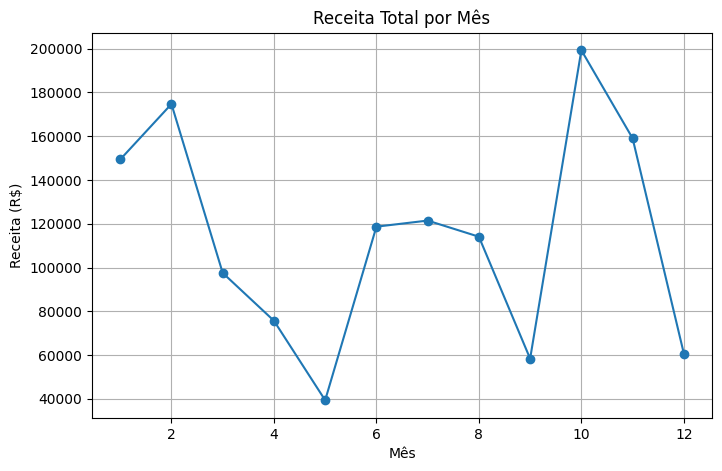

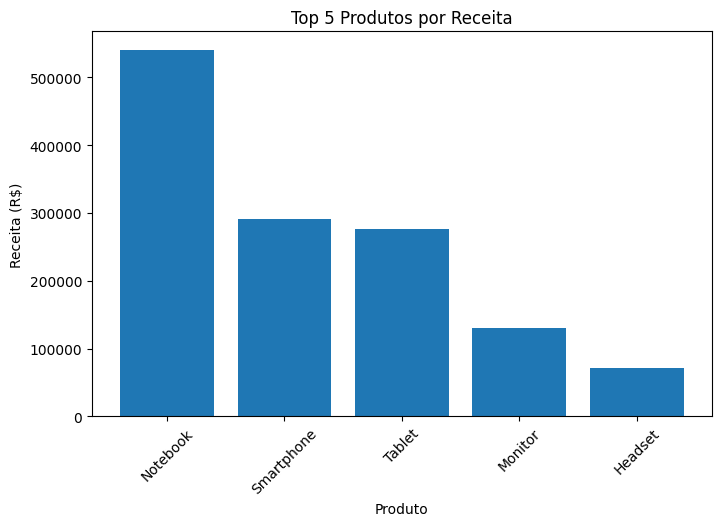

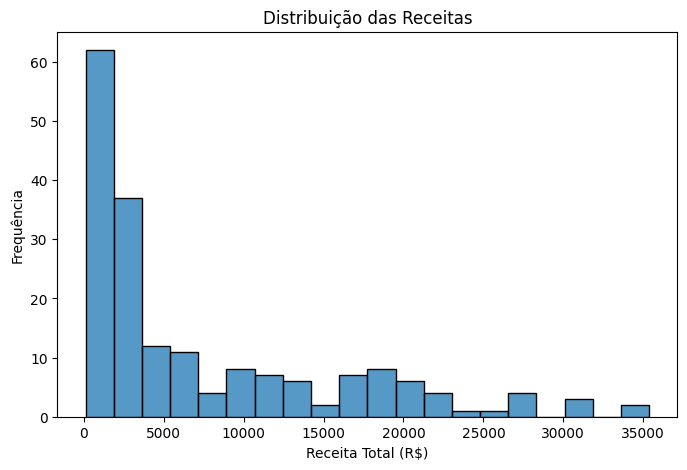


Arquivos gerados:
✓ grafico_receita_mes.png
✓ grafico_top5_produtos.png
✓ grafico_histograma_receitas.png

Receita Total:
R$ 1368314.74

Top 5 Produtos:
produto
Notebook      540697.12
Smartphone    291135.08
Tablet        276703.29
Monitor       130520.70
Headset        71676.81
Name: receita_total, dtype: float64

Projeção:
R$ 1505146.21

PIPELINE EXECUTADO COM SUCESSO!


C:\Users\rafad\AppData\Local\Temp\ipykernel_22116\2817644186.py:8: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json(


In [68]:
if __name__ == "__main__":
    main()


SALESINSIGHT PY

=== INÍCIO DA LIMPEZA ===

Nulos antes da limpeza:
data_venda         0
cliente            0
produto            0
categoria          0
quantidade         7
preco_unitario     3
valor_total       10
regiao             0
dtype: int64

Datas inválidas encontradas: 5

Registros removidos: 15

Nulos após limpeza:
data_venda        0
cliente           0
produto           0
categoria         0
quantidade        0
preco_unitario    0
valor_total       0
regiao            0
dtype: int64

Shape após limpeza:
(185, 8)

=== LIMPEZA CONCLUÍDA ===

=== RECEITA E QUANTIDADE POR MÊS ===
     receita_total  quantidade
mes                           
1        149359.17       108.0
2        174702.68       130.0
3         97550.03        85.0
4         75696.78        69.0
5         39390.11        42.0
6        118670.51        94.0
7        121455.71       101.0
8        114086.50        86.0
9         58376.22        62.0
10       199277.39       111.0
11       159033.64       104.0
1

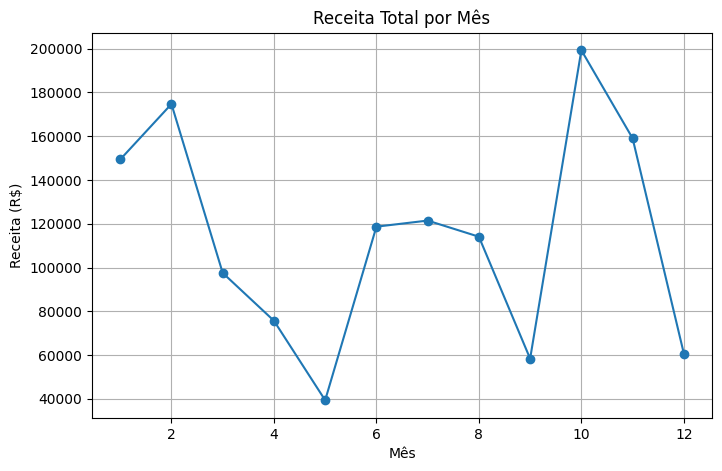

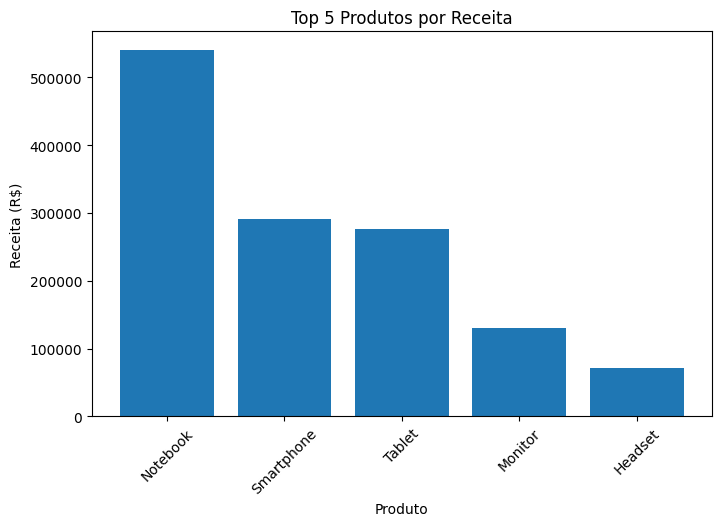

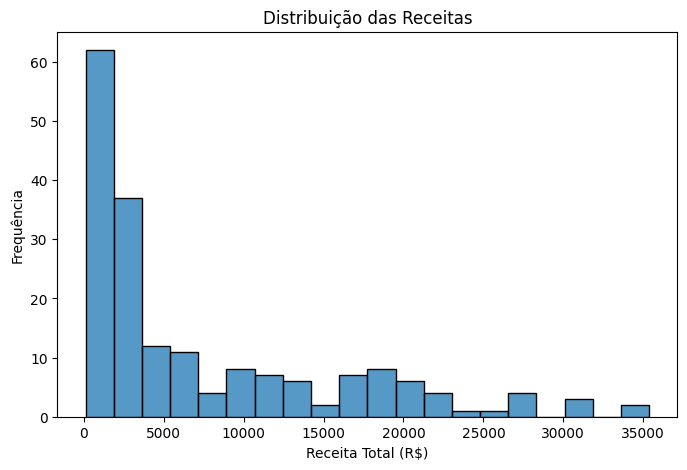


Arquivos gerados:
✓ grafico_receita_mes.png
✓ grafico_top5_produtos.png
✓ grafico_histograma_receitas.png

Receita Total:
R$ 1368314.74

Top 5 Produtos:
produto
Notebook      540697.12
Smartphone    291135.08
Tablet        276703.29
Monitor       130520.70
Headset        71676.81
Name: receita_total, dtype: float64

Projeção:
R$ 1505146.21

PIPELINE EXECUTADO COM SUCESSO!


C:\Users\rafad\AppData\Local\Temp\ipykernel_22116\2817644186.py:8: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df.to_json(


In [69]:
main()